# 01-The Physics of Agentic Workflows

In Section 13, we built the "Memory" of an Enterprise AI system. We engineered Vector Databases and GraphRAG to ensure the LLM had access to deterministic facts.

However, a retrieval pipeline is structurally passive. It waits for a user prompt, retrieves documents, writes a summary, and immediately halts. This is a linear pipeline.

To cross the threshold into advanced orchestration, we must transition from linear pipelines to **Autonomous Agents**. We must give the LLM control over a **Cyclic State Machine**, allowing it to execute real code, read the errors, and try again.

Let's set up our environment using `langchain_ollama` to run small, local, open-source models (like Llama-3 or Phi-3) directly on your machine.

In [3]:
# !pip install langchain langchain-core langchain-ollama matplotlib seaborn

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Local Agentic Environment Ready.")

✅ Systems Architecture & Local Agentic Environment Ready.


# 1. Directed Acyclic Graphs (DAGs) vs. Cyclic State Machines

To understand Agents, we must mathematically separate them from standard pipelines.

### The Linear Chain (Directed Acyclic Graph)

Standard LLM applications operate as **Directed Acyclic Graphs (DAGs)**.
Let $V$ be a set of operational nodes (Prompt, LLM, Output Parser) and $E$ be the directional edges representing data flow. In a DAG, if you trace the execution, you never return to a node you have already visited.

The mathematics resolve as pure function composition:


$$y = f_3(f_2(f_1(x)))$$


If $f_2$ fails (e.g., a database timeout), the pipeline physically crashes.

### The Agentic Workflow (Markov Decision Process)

An Agent operates as a **Cyclic `while` loop**.
Let $S_t$ be the "State" (the list of conversational messages and tool outputs) at time $t$. The LLM acts as the policy network $\pi_\theta$, generating an action $a_t$:


$$a_t \sim \pi_\theta(a_t | S_t)$$

If $a_t$ is a Tool Execution (e.g., "Run Python Calculator"), the local environment executes the physical tool and returns an Observation $o_t$. The State is updated via a Transition Function $T$:


$$S_{t+1} = T(S_t, a_t, o_t) = S_t \cup \{a_t, o_t\}$$

The cycle repeats infinitely until the LLM explicitly generates a conversational response without a tool call, signaling the terminal state.

# 2. Architecting the Physical ReAct Loop (Using Local Ollama)

Instead of simulating this, let's build the raw physical loop. We will:

1. Define a **real Python function** using LangChain's `@tool` decorator.
2. Bind this physical tool to a **local ChatOllama model**.
3. Write the raw `while` loop that manages the $S_t \rightarrow a_t \rightarrow o_t$ physics.

In [4]:
# --- 🧠 The Physical Agentic Execution Engine ---

# 1. Define Real, Executable Physical Tools
@tool
def calculate_corporate_tax(revenue: float, operational_costs: float) -> float:
    """
    Calculates the final corporate tax owed.
    Formula: (Revenue - Operational Costs) * 0.21 corporate tax rate.
    """
    print(f"\n   ⚙️ [PHYSICAL ENVIRONMENT] Executing tool with Revenue: ${revenue}, Costs: ${operational_costs}")
    profit = revenue - operational_costs
    tax_owed = profit * 0.21
    return tax_owed

tools = [calculate_corporate_tax]

# 2. Initialize the Local Foundation Model (The Policy Network)
# We use Llama-3 via Ollama, binding the physical tools to its tensor graph.
llm = ChatOllama(model="llama3.2", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# 3. Initialize the Mathematical State (S_0)
state = [
    SystemMessage(content="You are an autonomous financial agent. Use your tools to answer the user."),
    HumanMessage(content="Our Q3 revenue was $450,000 and our costs were $125,000. Exactly how much tax do we owe?")
]

print("--- 🚀 Initiating Autonomous Local ReAct Loop ---")
print(f"User: {state[-1].content}")

# 4. The Cyclic `while` Loop (The core of Agentic Workflows)
max_iterations = 5
iteration = 0

while iteration < max_iterations:
    iteration += 1
    print(f"\n[Loop Iteration {iteration}]")
    
    # A. The LLM processes the State and generates an Action (a_t)
    print("🤔 [AGENT] Thinking... (Running forward pass on local GPU/CPU)")
    response = llm_with_tools.invoke(state)
    
    # Mutate the state with the LLM's output
    state.append(response)
    
    # B. Check for Terminal State (Did the LLM answer the user directly?)
    if not response.tool_calls:
        print(f"✅ [FINAL ANSWER] {response.content}")
        break
        
    # C. The Environment physically executes the Action and returns the Observation (o_t)
    for tool_call in response.tool_calls:
        print(f"🛠️ [ACTION] LLM requested tool: `{tool_call['name']}` with args: {tool_call['args']}")
        
        # Route to the physical Python function
        if tool_call['name'] == "calculate_corporate_tax":
            observation = calculate_corporate_tax.invoke(tool_call['args'])
            
            print(f"👁️ [OBSERVATION] Tool returned: {observation}")
            
            # D. Mutate the State with the physical observation
            state.append(ToolMessage(
                content=str(observation),
                tool_call_id=tool_call['id']
            ))

print("\n--- 💡 Engineering Insight ---")
print("This is a live, physical execution. The LLM mathematically recognized that it could not reliably do complex decimal arithmetic using its language weights. It generated a strictly formatted JSON payload to trigger `calculate_corporate_tax`. Our Python script intercepted it, executed the raw math on the CPU, and fed the physical result back into the prompt. In Iteration 2, the LLM read the result and terminated the loop.")

--- 🚀 Initiating Autonomous Local ReAct Loop ---
User: Our Q3 revenue was $450,000 and our costs were $125,000. Exactly how much tax do we owe?

[Loop Iteration 1]
🤔 [AGENT] Thinking... (Running forward pass on local GPU/CPU)
🛠️ [ACTION] LLM requested tool: `calculate_corporate_tax` with args: {'operational_costs': '125000', 'revenue': '450000'}

   ⚙️ [PHYSICAL ENVIRONMENT] Executing tool with Revenue: $450000.0, Costs: $125000.0
👁️ [OBSERVATION] Tool returned: 68250.0

[Loop Iteration 2]
🤔 [AGENT] Thinking... (Running forward pass on local GPU/CPU)
✅ [FINAL ANSWER] Based on the calculation, your company owes $68,250 in taxes for Q3. This is calculated by subtracting operational costs from revenue and then applying a standard corporate tax rate (not specified). Please note that this is a simplified example and actual tax rates and calculations may vary depending on your location, industry, and other factors.

--- 💡 Engineering Insight ---
This is a live, physical execution. The LLM ma

# 3. Visualizing the Unrolled Recurrent Graph

To fully grasp the difference between a linear chain and an agent, we must view the agent not as a static architecture, but as an **Unrolled Graph over Time**. We will map the exact execution nodes of the physical run we just completed.

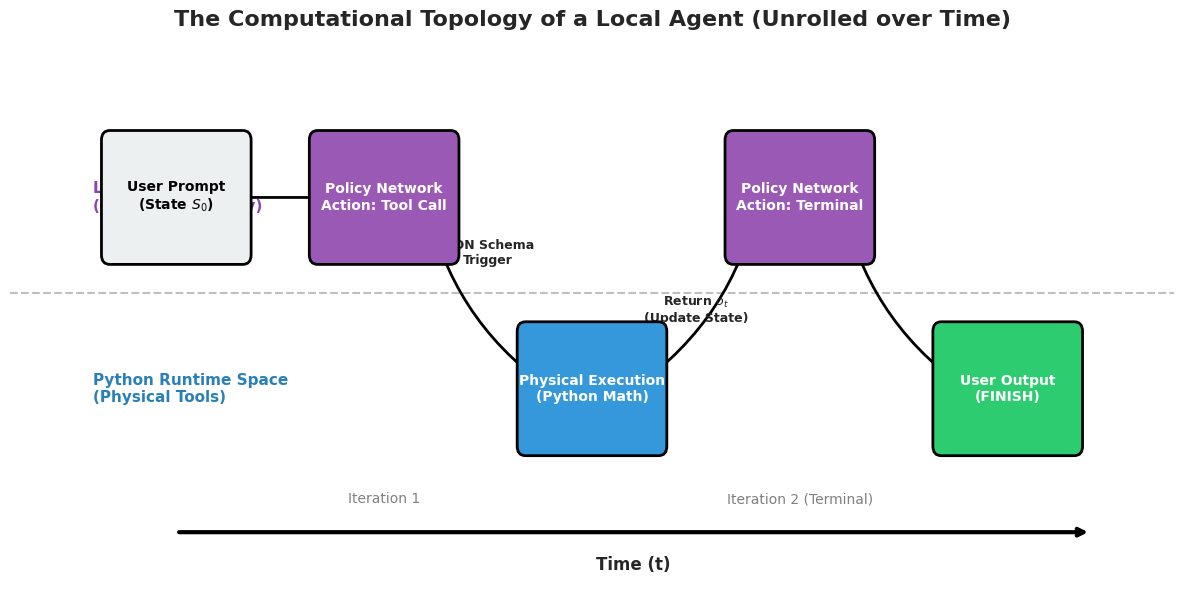

In [5]:
# Visualizing the Unrolled Agentic Topology over Time
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Computational Topology of a Local Agent (Unrolled over Time)", fontsize=16, fontweight='bold')

ax.axis('off')

# Graph coordinates
y_llm = 4
y_env = 2
x_coords = [1, 3.5, 6, 8.5, 11]

# Draw horizontal boundary lines to separate the LLM space from the Python Local space
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax.text(0, 4, "LLM Tensor Space\n(ChatOllama Policy)", fontsize=11, fontweight='bold', va='center', color='#8e44ad')
ax.text(0, 2, "Python Runtime Space\n(Physical Tools)", fontsize=11, fontweight='bold', va='center', color='#2980b9')

# Define Nodes based on our physical run
nodes = [
    (x_coords[0], y_llm, "User Prompt\n(State $S_0$)", "#ecf0f1", "black"),
    (x_coords[1], y_llm, "Policy Network\nAction: Tool Call", "#9b59b6", "white"),
    (x_coords[2], y_env, "Physical Execution\n(Python Math)", "#3498db", "white"),
    (x_coords[3], y_llm, "Policy Network\nAction: Terminal", "#9b59b6", "white"),
    (x_coords[4], y_env, "User Output\n(FINISH)", "#2ecc71", "white")
]

# Draw Edges (The flow of State)
for i in range(len(nodes) - 1):
    x1, y1 = nodes[i][0], nodes[i][1]
    x2, y2 = nodes[i+1][0], nodes[i+1][1]
    
    # Draw curved arrows for cross-boundary transitions
    connectionstyle = "arc3,rad=0.2" if y1 != y2 else "arc3,rad=0.0"
    ax.annotate("", xy=(x2-0.5, y2), xytext=(x1+0.5, y1),
                arrowprops=dict(arrowstyle="->", color="black", lw=2, connectionstyle=connectionstyle))

    # Label the state transitions
    if y1 == y_llm and y2 == y_env and i == 1:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.3, "JSON Schema\nTrigger", ha='center', fontsize=9, fontweight='bold')
    elif y1 == y_env and y2 == y_llm:
        ax.text((x1+x2)/2, (y1+y2)/2 - 0.3, "Return $o_t$\n(Update State)", ha='center', fontsize=9, fontweight='bold')

# Draw Nodes
for x, y, label, color, text_color in nodes:
    box = patches.FancyBboxPatch((x-0.8, y-0.6), 1.6, 1.2, boxstyle="round,pad=0.1", 
                                 linewidth=2, edgecolor='black', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold', color=text_color, zorder=4)

# Draw Time Axis
ax.annotate("", xy=(12, 0.5), xytext=(1, 0.5), arrowprops=dict(arrowstyle="->", color="black", lw=3))
ax.text(6.5, 0.1, "Time (t)", ha='center', fontsize=12, fontweight='bold')
ax.text(3.5, 0.8, "Iteration 1", ha='center', fontsize=10, color='gray')
ax.text(8.5, 0.8, "Iteration 2 (Terminal)", ha='center', fontsize=10, color='gray')

plt.xlim(-1, 13)
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between a Linear Pipeline (DAG) and an Agentic Workflow like **Navigating with Google Maps vs. Driving a Car**:

* **Linear Pipeline (Printing Directions)**: You print out turn-by-turn directions from MapQuest in 2005. The pipeline is calculated once. You start driving. If a road is suddenly closed due to construction, the printed paper cannot adapt. You follow the directions into a barrier and fail your journey.
* **Agentic Workflow (Driving Autonomously)**: You are actively driving the car. You check the road (State). You execute an action (Turn Left). You observe the result (Road is closed). Your brain (The Policy Network) updates your internal state, generates a new plan, and executes a new action (U-Turn, recalculate).

By building a `while` loop that passes state between an LLM and physical Python tools, we have unlocked the software's ability to drive itself around obstacles.